In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
!pip install -q transformers accelerate pillow matplotlib opencv-python

In [29]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation,
)

In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = SegformerImageProcessor.from_pretrained(
    "jonathandinu/face-parsing"
)

model = SegformerForSemanticSegmentation.from_pretrained(
    "jonathandinu/face-parsing"
)

model.to(device)
model.eval()

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (stages): ModuleList(
      (0): SegformerStage(
        (patch_embeddings): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (blocks): ModuleList(
          (0): SegformerLayer(
            (layernorm_before): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (attention): SegformerAttention(
              (q_proj): Linear(in_features=64, out_features=64, bias=True)
              (k_proj): Linear(in_features=64, out_features=64, bias=True)
              (v_proj): Linear(in_features=64, out_features=64, bias=True)
              (o_proj): Linear(in_features=64, out_features=64, bias=True)
              (sequence_reduction): SegformerSequenceReduction(
                (sequence_reduction): Conv2d(64, 64, kernel_size=(8, 8), stride=(8, 8))
        

In [52]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-07-10 164347.png to Screenshot 2026-07-10 164347.png


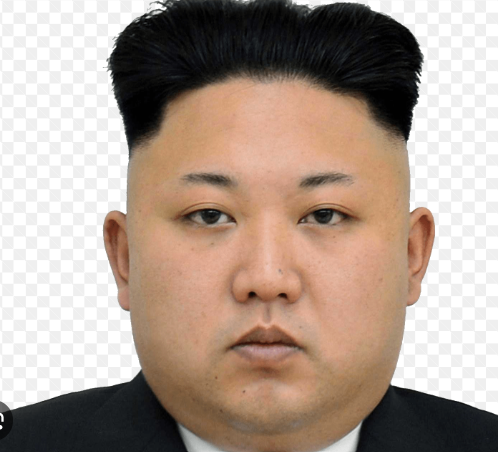

In [53]:
image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")
image

In [54]:
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

In [55]:
logits = outputs.logits

upsampled_logits = torch.nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False,
)

labels = upsampled_logits.argmax(dim=1)[0]
labels = labels.cpu().numpy()

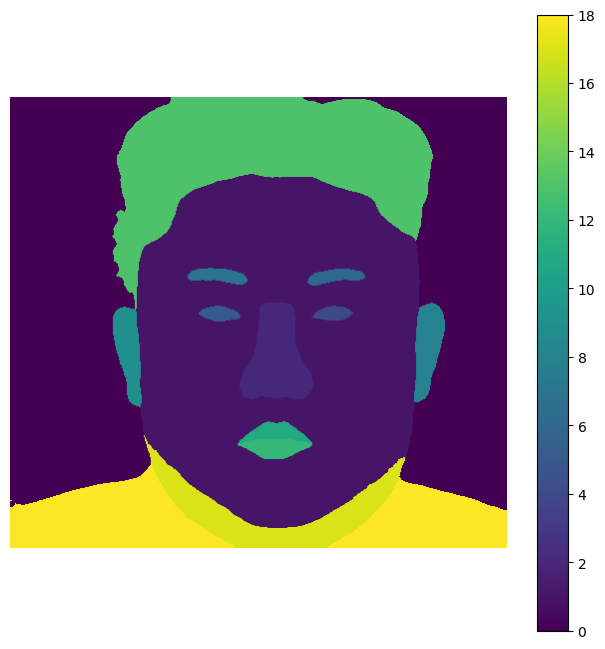

In [56]:
plt.figure(figsize=(8,8))
plt.imshow(labels)
plt.colorbar()
plt.axis("off")
plt.show()

In [36]:
label_map = {
    0: "background",
    1: "skin",
    2: "nose",
    3: "eye_g",
    4: "left_eye",
    5: "right_eye",
    6: "left_eyebrow",
    7: "right_eyebrow",
    8: "left_ear",
    9: "right_ear",
    10: "mouth",
    11: "upper_lip",
    12: "lower_lip",
    13: "hair",
    14: "hat",
    15: "earring",
    16: "necklace",
    17: "neck",
    18: "cloth",
}

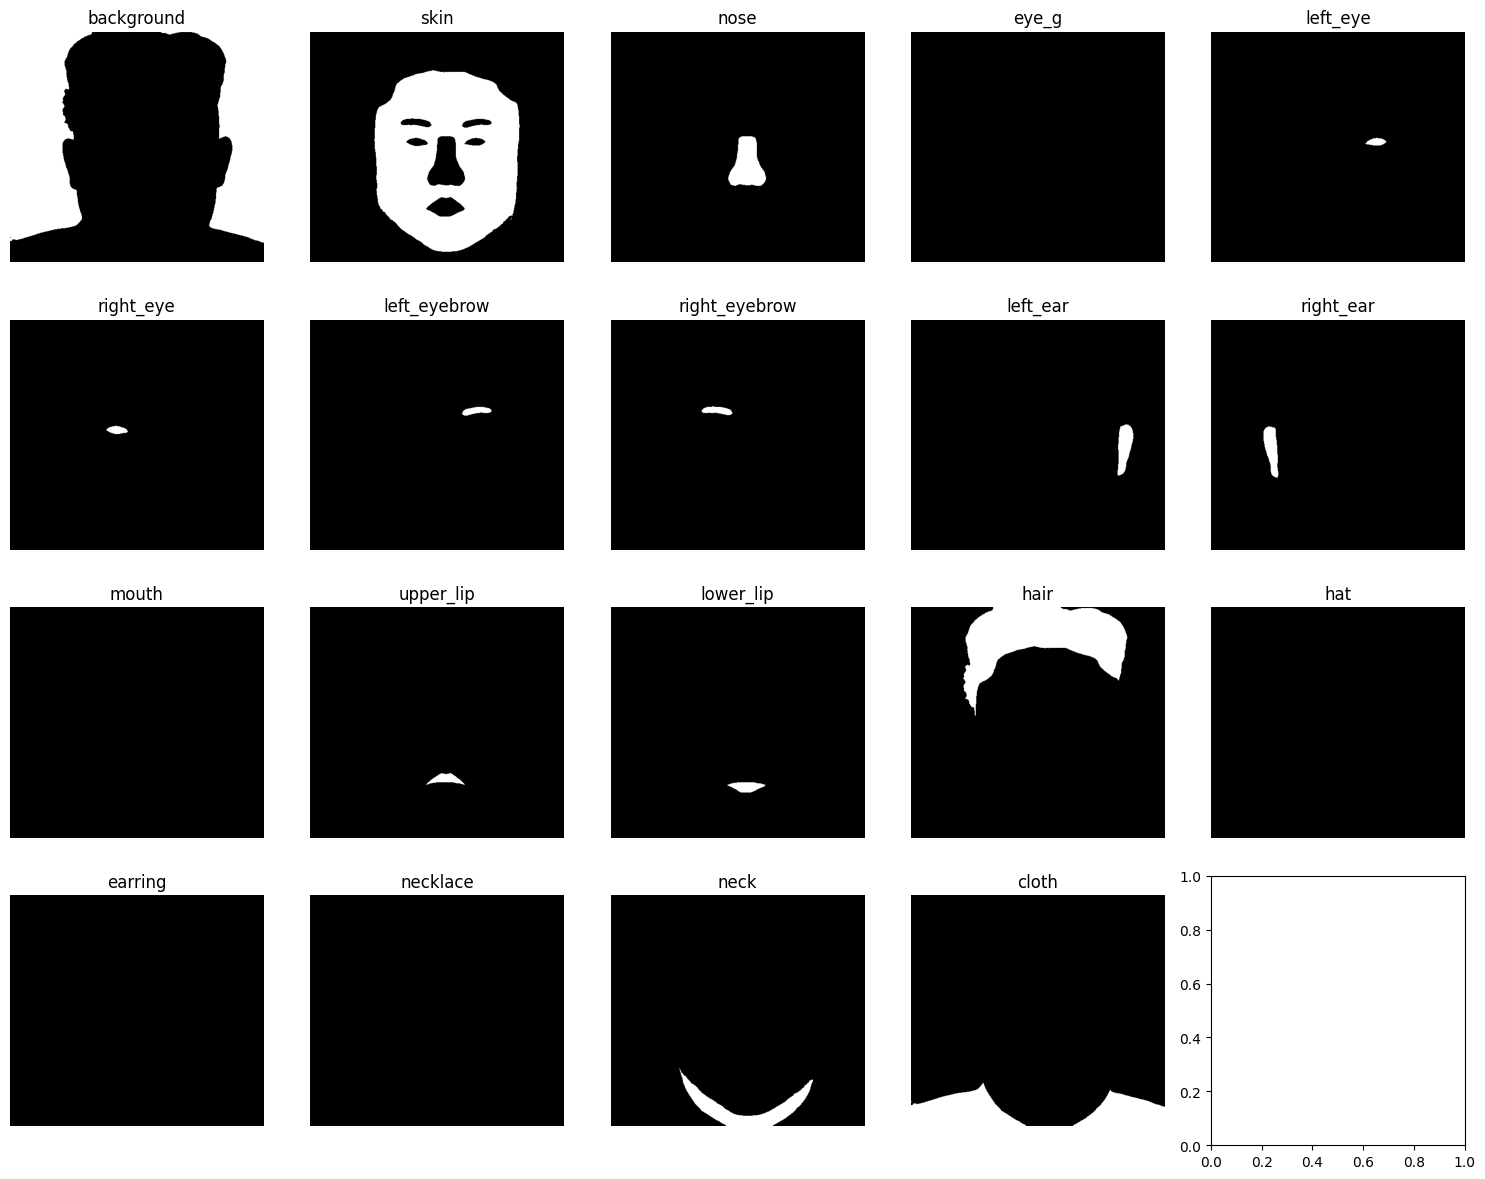

In [57]:
fig, axes = plt.subplots(4,5, figsize=(15,12))

axes = axes.flatten()

for idx, name in label_map.items():
    mask = (labels == idx)

    axes[idx].imshow(mask, cmap="gray")
    axes[idx].set_title(name)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [38]:
import os
img = np.array(image)

os.makedirs("parts-2", exist_ok=True)

for idx, name in label_map.items():

    mask = (labels == idx)

    part = np.zeros_like(img)
    part[mask] = img[mask]

    cv2.imwrite(
        f"parts-2/{name}.png",
        cv2.cvtColor(part, cv2.COLOR_RGB2BGR)
    )

In [22]:
os.makedirs("parts-cropped-2", exist_ok=True)

In [39]:
for idx, name in label_map.items():

    mask = (labels == idx).astype(np.uint8)

    ys, xs = np.where(mask)

    if len(xs) == 0:
        continue

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    crop = np.array(image)[y1:y2+1, x1:x2+1]

    Image.fromarray(crop).save(f"parts-cropped-2/{name}_crop.png")

In [40]:
!zip -r /content/parts-2.zip /content/parts-2


  adding: content/parts-2/ (stored 0%)
  adding: content/parts-2/necklace.png (deflated 95%)
  adding: content/parts-2/left_eyebrow.png (deflated 44%)
  adding: content/parts-2/earring.png (deflated 95%)
  adding: content/parts-2/upper_lip.png (deflated 45%)
  adding: content/parts-2/hat.png (deflated 95%)
  adding: content/parts-2/right_eyebrow.png (deflated 44%)
  adding: content/parts-2/nose.png (deflated 20%)
  adding: content/parts-2/cloth.png (deflated 4%)
  adding: content/parts-2/hair.png (deflated 4%)
  adding: content/parts-2/left_eye.png (deflated 52%)
  adding: content/parts-2/lower_lip.png (deflated 45%)
  adding: content/parts-2/background.png (deflated 3%)
  adding: content/parts-2/skin.png (deflated 3%)
  adding: content/parts-2/neck.png (deflated 11%)
  adding: content/parts-2/right_ear.png (deflated 31%)
  adding: content/parts-2/mouth.png (deflated 95%)
  adding: content/parts-2/left_ear.png (deflated 40%)
  adding: content/parts-2/eye_g.png (deflated 95%)
  adding: 

In [41]:

# 2. Trigger the browser download
from google.colab import files
files.download('/content/parts-2.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

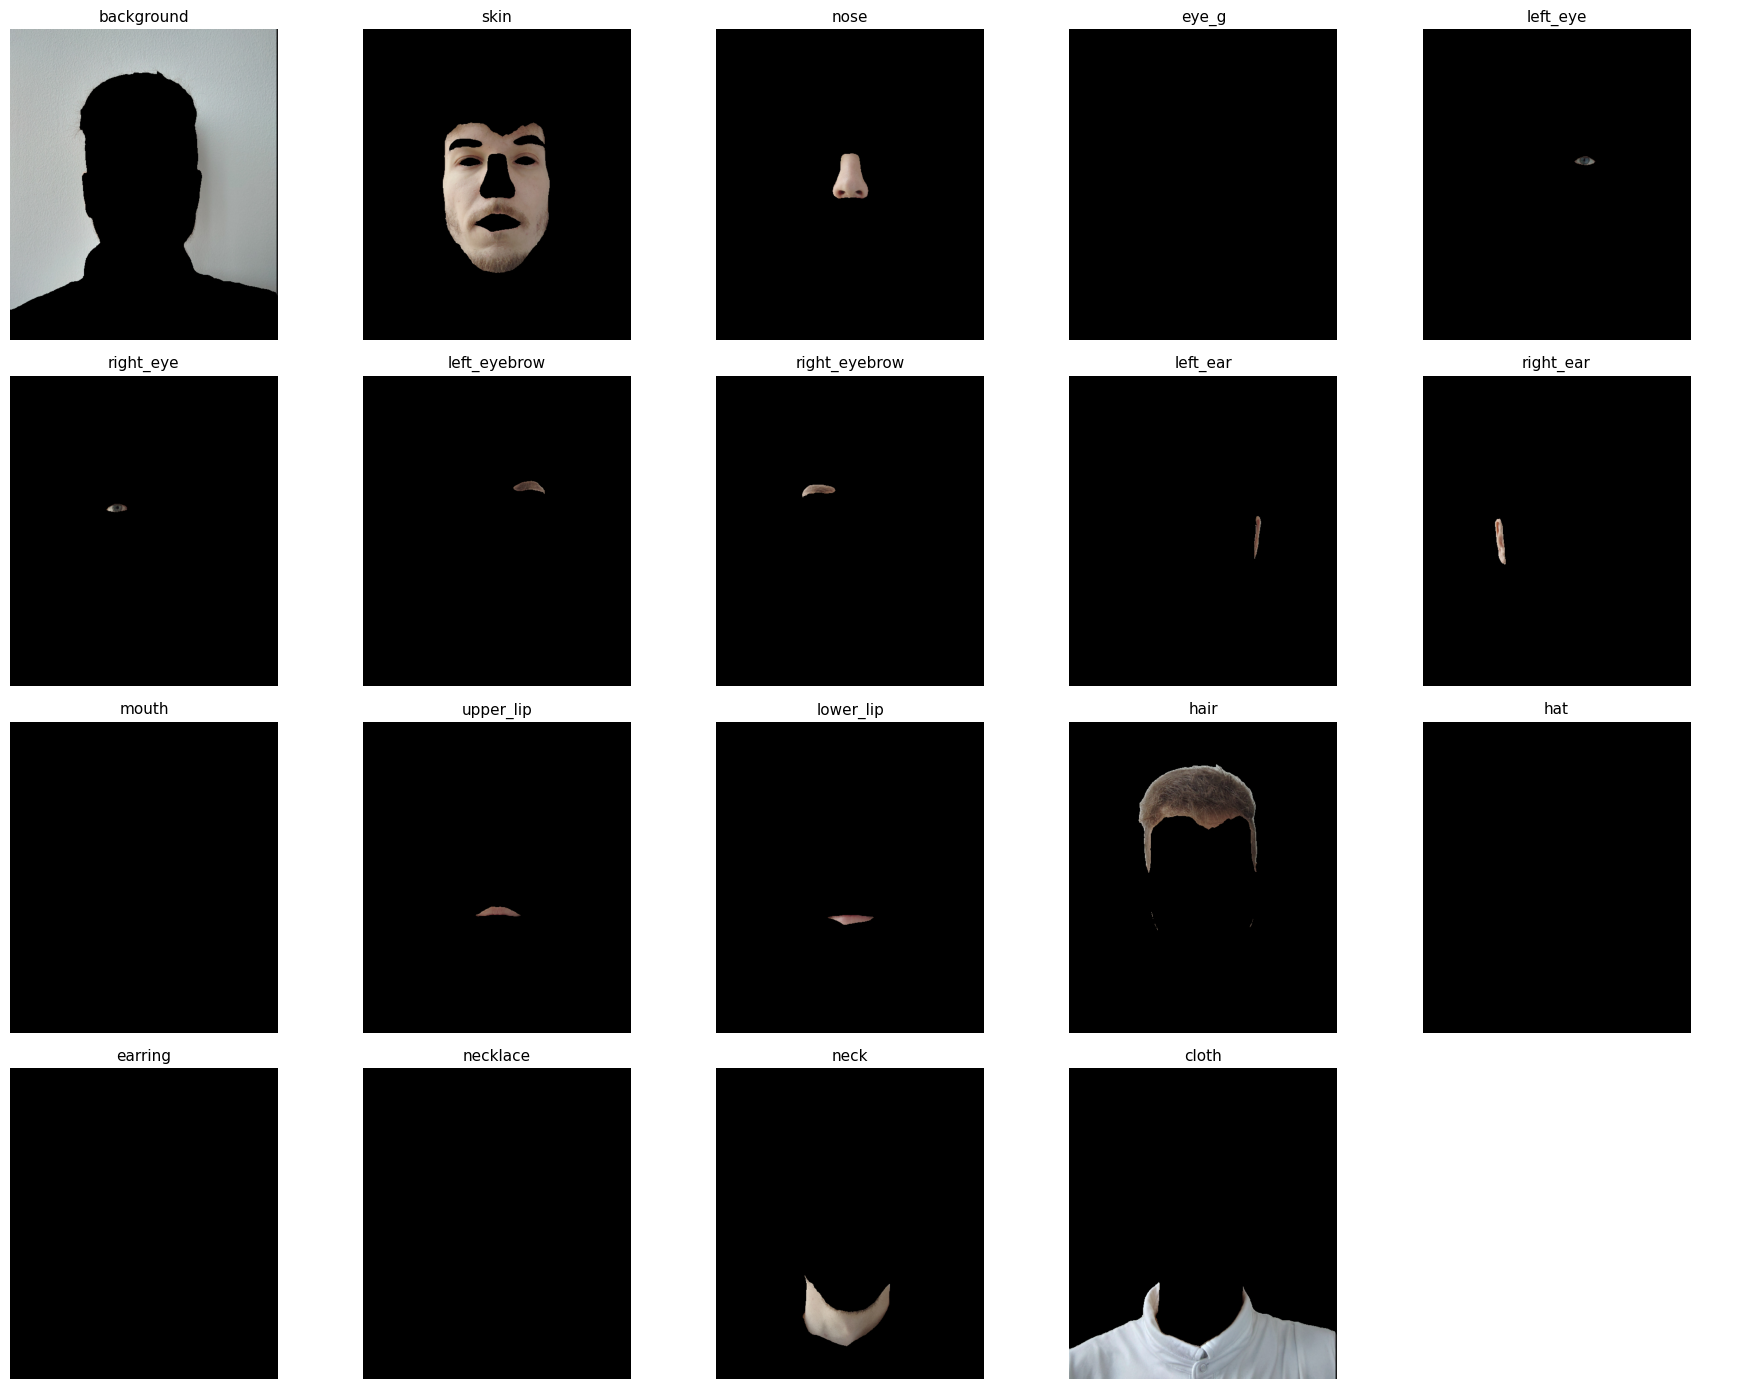

In [45]:
import numpy as np
import matplotlib.pyplot as plt

img = np.array(image)

rows = 4
cols = 5

fig, axes = plt.subplots(rows, cols, figsize=(18,14))
axes = axes.flatten()

for idx in range(len(label_map)):

    mask = labels == idx

    part = np.zeros_like(img)
    part[mask] = img[mask]

    axes[idx].imshow(part)
    axes[idx].set_title(label_map[idx], fontsize=11)
    axes[idx].axis("off")

for i in range(len(label_map), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [46]:
for i in range(len(label_map), len(axes)):
    axes[i].axis("off")

plt.tight_layout()

# Save the figure BEFORE plt.show()
plt.savefig("my_segmented_image.png", dpi=300, bbox_inches='tight')

plt.show()

<Figure size 640x480 with 0 Axes>

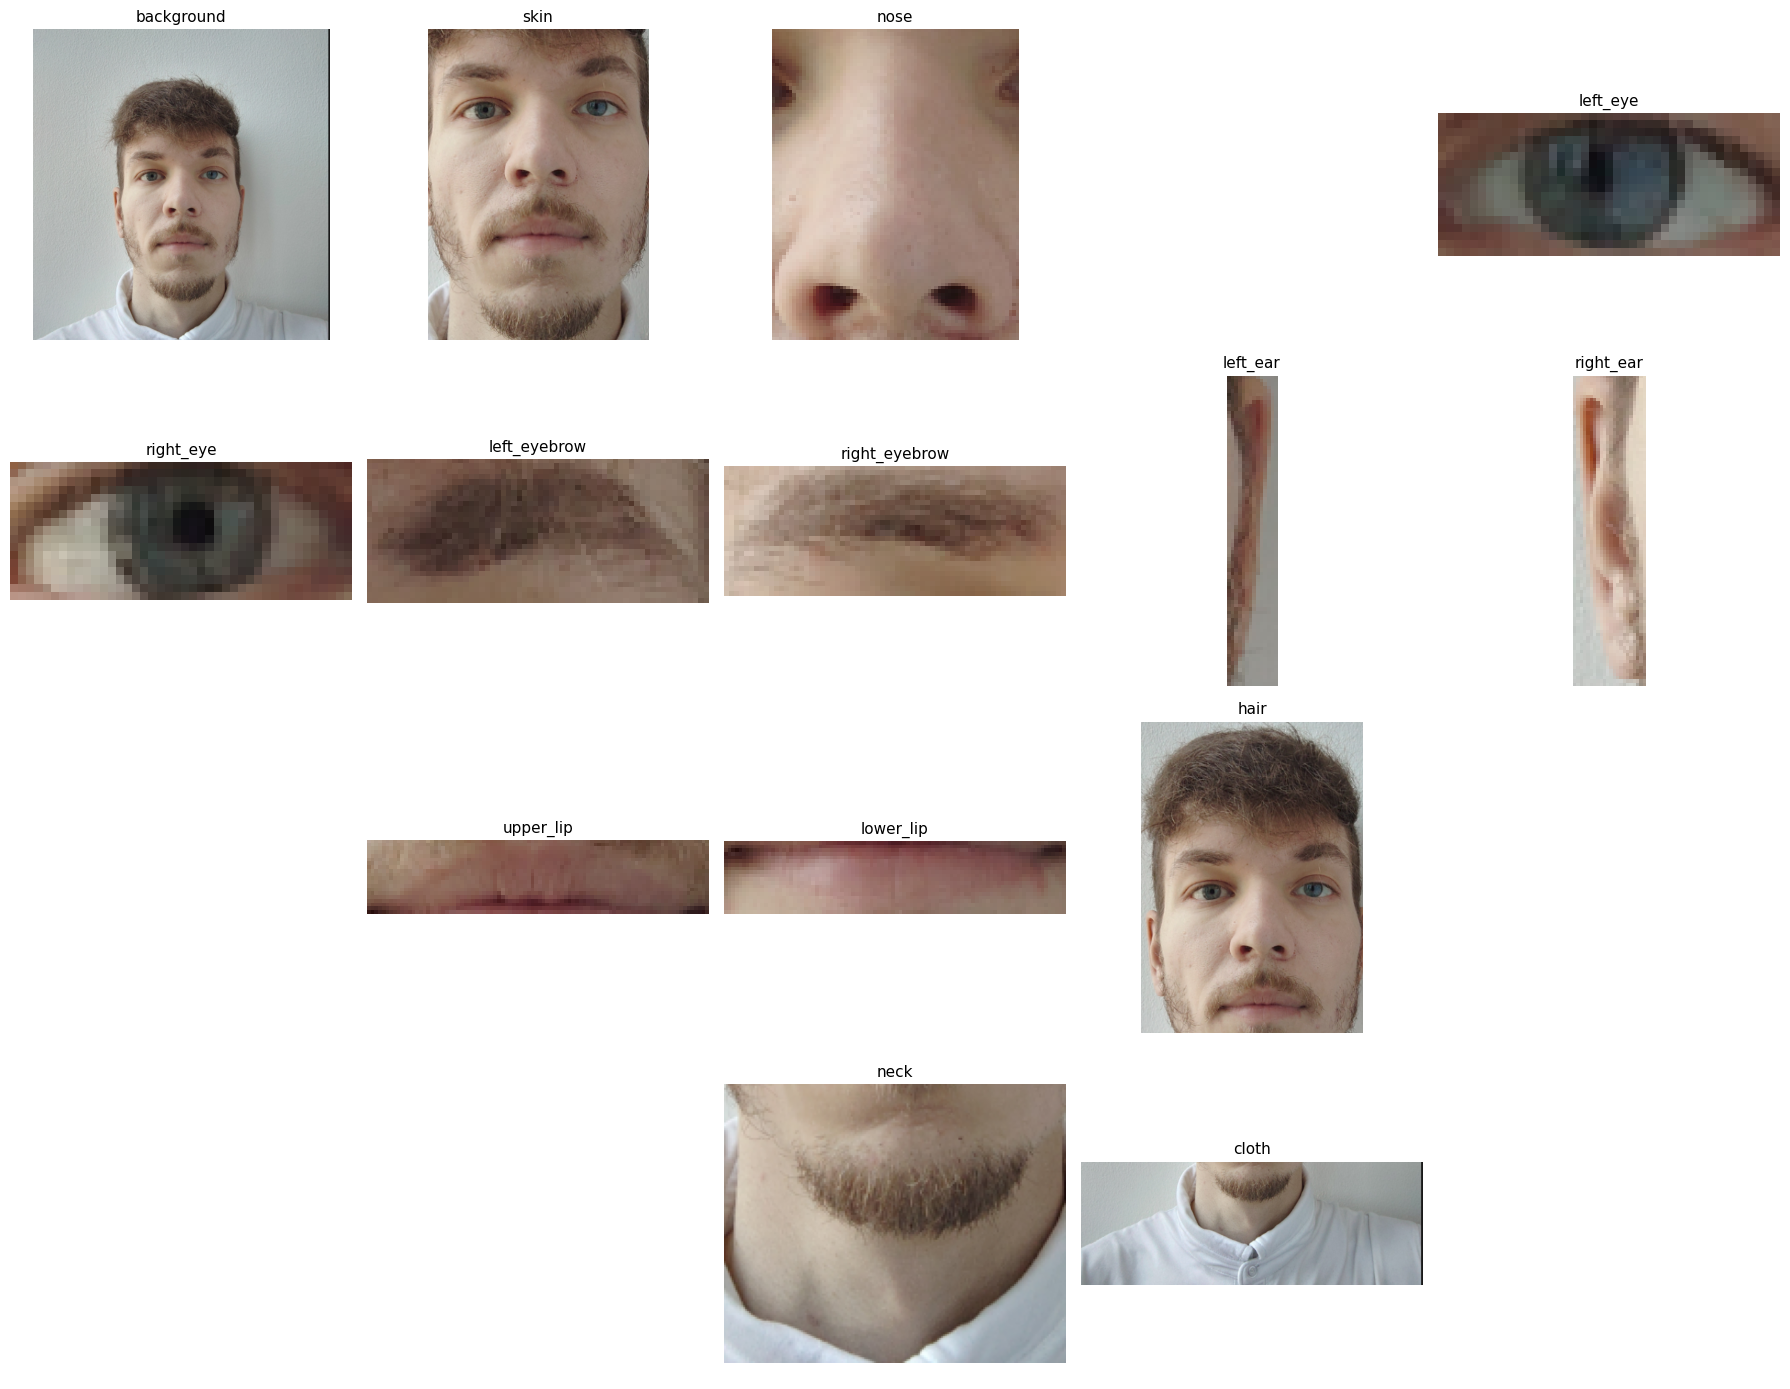

In [43]:
import numpy as np
import matplotlib.pyplot as plt

img = np.array(image)

rows = 4
cols = 5

fig, axes = plt.subplots(rows, cols, figsize=(18,14))
axes = axes.flatten()

for idx in range(len(label_map)):

    mask = (labels == idx)

    ys, xs = np.where(mask)

    if len(xs) == 0:
        axes[idx].axis("off")
        continue

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    crop = img[y1:y2+1, x1:x2+1]

    axes[idx].imshow(crop)
    axes[idx].set_title(label_map[idx], fontsize=11)
    axes[idx].axis("off")

for i in range(len(label_map), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [44]:
plt.tight_layout()

plt.savefig(
    "all_body_parts.png",
    dpi=300,
    bbox_inches="tight"
)


<Figure size 640x480 with 0 Axes>